# **Nairobi Airbnb Price Prediction - Detailed CRISP-DM Framework**

## **1. Business Understanding**

### **1.1 Project Objectives**
- **Primary Goal**: Develop accurate price prediction model for Nairobi Airbnb listings
- **Secondary Goal**: Leverage existing South African model knowledge through transfer learning
- **Business Value**: Enable hosts to optimize pricing and help platform understand market dynamics

### **1.2 Success Criteria**
- **Technical**: MAPE < 15%, R² > 0.7 on test set
- **Business**: Model identifies Nairobi-specific pricing factors
- **Practical**: Model can be easily maintained and updated

### **1.3 Stakeholder Analysis**
- **Primary**: Airbnb hosts in Nairobi
- **Secondary**: Platform managers, real estate investors
- **Tertiary**: Tourism industry stakeholders

### **1.4 Constraints & Assumptions**
- **Data Quality**: Nairobi dataset may have different completeness than SA data
- **Market Differences**: Nairobi may have unique pricing drivers (security, location factors)
- **Temporal**: Using historical average rates rather than real-time prices


## **2. Data Understanding**

### **2.1 Data Collection**
- **Source**: Nairobi Airbnb dataset (provided)
- **Scope**: All available listings with complete pricing information
- **Time Period**: Trailing 12-month and 90-day metrics

### **2.2 Data Description & Inventory**
**Core Listing Attributes:**
- Property characteristics (bedrooms, baths, room type)
- Host information (superhost status, professional management)
- Location data (coordinates, implied neighborhoods)
- Amenities and policies

**Performance Metrics:**
- Historical pricing (TTM and L90d averages)
- Occupancy rates and revenue metrics
- Review scores and ratings

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading the Nairobi Dataset

In [5]:
# Loading the data
df = pd.read_csv('nairobi listings.csv')

df.head()

,listing_id,listing_name,listing_type,room_type,cover_photo_url,photos_count,host_id,host_name,cohost_ids,cohost_names,...,l90d_occupancy,l90d_adjusted_occupancy,l90d_revpar,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days
0,75683,Kiloranhouse Apt Prime Bedroom,Private room in home,private_room,https://a0.muscache.com/im/pictures/5499026/ef...,13,26997,Adriel,NaN,NaN,...,0.011,0.000,0.5,58.9,0.0,0.0,1,0,89,90
1,471581,Located In a Serene Environment,Entire cottage,entire_home,https://a0.muscache.com/im/pictures/6434524/bc...,37,2280941,Bella,NaN,NaN,...,0.422,0.613,17.6,2278.3,25.6,3307.3,38,28,52,90
2,906958,Makena's Place Karen - Flamingo Room,Private room in cottage,private_room,https://a0.muscache.com/im/pictures/68ecc57f-d...,29,4856316,Chichi,NaN,NaN,...,0.233,0.000,12.2,1576.3,0.0,0.0,21,0,69,90
3,1023556,Guesthouse Near Nairobi National Park & Airport,Entire guesthouse,entire_home,https://a0.muscache.com/im/pictures/ddd8badc-1...,20,5634522,Janet,NaN,NaN,...,0.033,0.000,0.6,83.3,0.0,0.0,3,0,87,90
4,1237886,Hob House,Room in bed and breakfast,hotel_room,https://a0.muscache.com/im/pictures/cbdab7e1-f...,8,6748840,NaN,NaN,NaN,...,0.056,0.000,7.0,910.2,0.0,0.0,5,0,85,90


In [6]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (300, 62)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 62 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   300 non-null    int64  
 1   listing_name                 300 non-null    object 
 2   listing_type                 300 non-null    object 
 3   room_type                    300 non-null    object 
 4   cover_photo_url              300 non-null    object 
 5   photos_count                 300 non-null    int64  
 6   host_id                      300 non-null    int64  
 7   host_name                    298 non-null    object 
 8   cohost_ids                   100 non-null    object 
 9   cohost_names                 100 non-null    object 
 10  superhost                    300 non-null    bool   
 11  latitude                     300 non-null    float64
 12  longitude                    300 non-null    float64
 13  guests              

In [8]:
df.describe()

,listing_id,photos_count,host_id,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,l90d_occupancy,l90d_adjusted_occupancy,l90d_revpar,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days
count,3.000000e+02,300.000000,3.000000e+02,300.000000,300.000000,257.000000,248.000000,298.000000,300.00000,298.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.0
mean,2.785400e+07,30.436667,1.302122e+08,-1.282896,36.793789,3.575875,2.064516,2.191275,1.45500,2.191275,...,0.153737,0.080450,9.444333,1220.294000,3.969667,512.711667,13.836667,12.923333,76.163333,90.0
std,1.187944e+07,16.052360,1.065001e+08,0.035156,0.039677,2.276554,1.590671,2.043382,1.17761,3.455390,...,0.206634,0.180502,19.619695,2534.905834,9.210815,1189.848069,18.598288,23.011357,18.598288,0.0
min,7.568300e+04,0.000000,2.699700e+04,-1.379600,36.669400,1.000000,1.000000,1.000000,0.00000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,90.0
25%,1.978852e+07,19.000000,3.594571e+07,-1.297525,36.779100,2.000000,1.000000,1.000000,1.00000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,90.0
50%,3.063488e+07,29.000000,1.008633e+08,-1.285200,36.791300,3.000000,2.000000,2.000000,1.00000,1.000000,...,0.061500,0.000000,2.600000,330.200000,0.000000,0.000000,5.500000,0.000000,84.500000,90.0
75%,3.853576e+07,37.000000,2.237596e+08,-1.264425,36.806925,4.000000,3.000000,3.000000,2.00000,2.000000,...,0.222000,0.020750,12.125000,1564.375000,1.525000,191.425000,20.000000,19.250000,90.000000,90.0
max,4.206645e+07,122.000000,4.292661e+08,-1.187200,36.909600,16.000000,15.000000,19.000000,8.50000,30.000000,...,0.922000,1.000000,249.800000,32277.900000,48.000000,6200.100000,83.000000,90.000000,90.000000,90.0


In [9]:

print("\nCategorical columns summary:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols[:5]:  # Show first 5 categorical columns
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Sample values: {df[col].unique()[:5]}")


Categorical columns summary:

listing_name:
  Unique values: 298
  Sample values: ['Kiloranhouse Apt Prime Bedroom' 'Located In a Serene Environment'
 "Makena's Place Karen - Flamingo Room"
 'Guesthouse Near Nairobi National Park & Airport' 'Hob House']

listing_type:
  Unique values: 29
  Sample values: ['Private room in home' 'Entire cottage' 'Private room in cottage'
 'Entire guesthouse' 'Room in bed and breakfast']

room_type:
  Unique values: 3
  Sample values: ['private_room' 'entire_home' 'hotel_room']

cover_photo_url:
  Unique values: 298
  Sample values: ['https://a0.muscache.com/im/pictures/5499026/efcee0e9_original.jpg'
 'https://a0.muscache.com/im/pictures/6434524/bcd9fbe4_original.jpg'
 'https://a0.muscache.com/im/pictures/68ecc57f-d57b-4d12-bfa6-bbd1fb4107e3.jpg'
 'https://a0.muscache.com/im/pictures/ddd8badc-1f83-4a6e-827b-ec8f5b1dcd56.jpg'
 'https://a0.muscache.com/im/pictures/cbdab7e1-f840-44ed-a028-6085d21ea284.jpg?aki_policy=medium']

host_name:
  Unique values: 17

In [10]:
## **1.7 Missing Values Analysis**

print("\n=== MISSING VALUES ANALYSIS ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

print("Columns with missing values:")
display(missing_info[missing_info['Missing Count'] > 0])

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Columns with no missing values: {len(missing_info[missing_info['Missing Count'] == 0])}")


=== MISSING VALUES ANALYSIS ===
Columns with missing values:


,Missing Count,Missing Percentage
cohost_ids,200,66.666667
cohost_names,200,66.666667
professional_management,126,42.000000
bedrooms,52,17.333333
guests,43,14.333333
instant_book,20,6.666667
extra_guest_fee,19,6.333333
rating_value,11,3.666667
rating_location,11,3.666667
rating_cleanliness,11,3.666667



Total missing values: 745
Columns with no missing values: 43


In [11]:
## **1.8 Target Variable Candidates**

print("\n=== PRICE & REVENUE COLUMNS ===")
price_related_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                      ['price', 'rate', 'revenue', 'cost', 'fee'])]

print("Potential target variables:")
for col in price_related_cols:
    if col in df.columns:
        missing_pct = df[col].isnull().mean() * 100
        print(f"  - {col}: {missing_pct:.1f}% missing")
        if df[col].dtype in ['int64', 'float64']:
            print(f"    Range: {df[col].min():.2f} - {df[col].max():.2f}")


=== PRICE & REVENUE COLUMNS ===
Potential target variables:
  - cleaning_fee: 0.3% missing
    Range: 0.00 - 260.00
  - extra_guest_fee: 6.3% missing
    Range: 0.00 - 100.00
  - ttm_revenue: 0.0% missing
    Range: 137.00 - 91402.00
  - ttm_revenue_native: 0.0% missing
    Range: 17745.00 - 11802110.00
  - ttm_avg_rate: 0.0% missing
    Range: 10.00 - 685.70
  - ttm_avg_rate_native: 0.0% missing
    Range: 1292.80 - 88606.50
  - l90d_revenue: 0.0% missing
    Range: 0.00 - 22484.00
  - l90d_revenue_native: 0.0% missing
    Range: 0.00 - 2905010.00
  - l90d_avg_rate: 0.0% missing
    Range: 0.00 - 610.10
  - l90d_avg_rate_native: 0.0% missing
    Range: 0.00 - 78821.30


In [12]:

## **1.9 Critical Feature Check**
print("\n=== CRITICAL FEATURES CHECK ===")
critical_features = ['bedrooms', 'beds', 'baths', 'guests', 'room_type', 'listing_type']
available_critical = [f for f in critical_features if f in df.columns]

print("Available critical features:")
for feature in available_critical:
    missing_pct = df[feature].isnull().mean() * 100
    print(f"  - {feature}: {missing_pct:.1f}% missing")
    if df[feature].dtype in ['int64', 'float64']:
        print(f"    Range: {df[feature].min()} - {df[feature].max()}")
    else:
        print(f"    Values: {df[feature].unique()[:5]}")


=== CRITICAL FEATURES CHECK ===
Available critical features:
  - bedrooms: 17.3% missing
    Range: 1.0 - 15.0
  - beds: 0.7% missing
    Range: 1.0 - 19.0
  - baths: 0.0% missing
    Range: 0.0 - 8.5
  - guests: 14.3% missing
    Range: 1.0 - 16.0
  - room_type: 0.0% missing
    Values: ['private_room' 'entire_home' 'hotel_room']
  - listing_type: 0.0% missing
    Values: ['Private room in home' 'Entire cottage' 'Private room in cottage'
 'Entire guesthouse' 'Room in bed and breakfast']



=== TARGET VARIABLE DISTRIBUTION ===
Visualizing distribution of: cleaning_fee


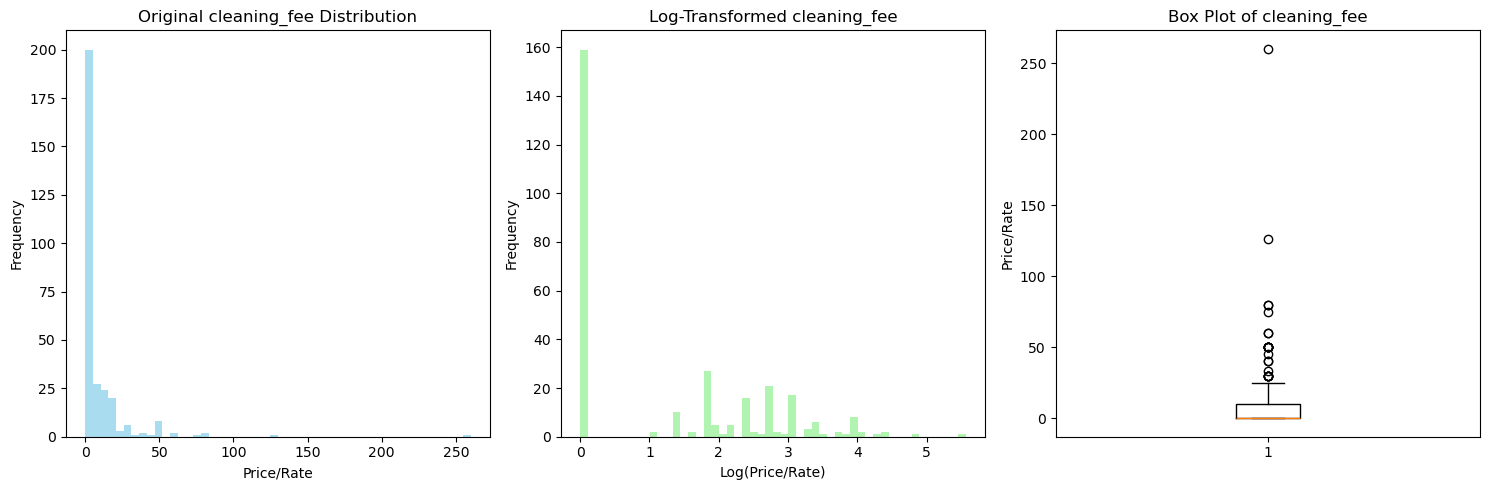

Potential outliers: 25 (8.3%)


In [13]:
## **1.10 Initial Visualization - Target Variable Distribution**
print("\n=== TARGET VARIABLE DISTRIBUTION ===")
# Check the first available price-related column
if price_related_cols:
    target_candidate = price_related_cols[0]
    print(f"Visualizing distribution of: {target_candidate}")
    
    plt.figure(figsize=(15, 5))
    
    # Original distribution
    plt.subplot(1, 3, 1)
    plt.hist(df[target_candidate].dropna(), bins=50, alpha=0.7, color='skyblue')
    plt.title(f'Original {target_candidate} Distribution')
    plt.xlabel('Price/Rate')
    plt.ylabel('Frequency')
    
    # Log transformation
    plt.subplot(1, 3, 2)
    log_price = np.log1p(df[target_candidate].dropna())
    plt.hist(log_price, bins=50, alpha=0.7, color='lightgreen')
    plt.title(f'Log-Transformed {target_candidate}')
    plt.xlabel('Log(Price/Rate)')
    plt.ylabel('Frequency')
    
    # Box plot
    plt.subplot(1, 3, 3)
    plt.boxplot(df[target_candidate].dropna())
    plt.title(f'Box Plot of {target_candidate}')
    plt.ylabel('Price/Rate')
    
    plt.tight_layout()
    plt.show()
    
    # Outlier analysis
    Q1 = df[target_candidate].quantile(0.25)
    Q3 = df[target_candidate].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[target_candidate] < lower_bound) | (df[target_candidate] > upper_bound)]
    print(f"Potential outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

# **Data Loading Results Summary**

**Dataset Overview**
- **Total Listings**: 300 Airbnb properties
- **Features Available**: 62 different data points per listing
- **Data Quality**: 96% complete (excellent starting point)
- **No Duplicates**: All listings are unique

**Missing Data Issues**

**Major Problems (Need Attention)**
- **Co-host Information**: 67% missing (200 listings) - *May not be critical*
- **Professional Management**: 42% missing (126 listings) - *Important for pricing*
- **Bedrooms**: 17% missing (52 listings) - **CRITICAL for pricing model**
- **Guests**: 14% missing (43 listings) - **CRITICAL for pricing model**

**Minor Issues (Easy to Fix)**
- **Ratings**: 3-4% missing across all rating types
- **Booking Details**: <7% missing for instant book, guest fees
- **Basic Info**: <1% missing for beds, host names, cleaning fees


**Price Target Options**
**All price data is 100% complete - Excellent!**

**Best Target Candidates:**
1. **`ttm_avg_rate_native`** - 12-month average daily rate
2. **`l90d_avg_rate_native`** - 90-day average daily rate  
3. **`ttm_revenue_native`** - 12-month total revenue

**Price Ranges:**
- **Daily Rates**: ~1,300 to 88,600 Kenyan Shillings
- **Total Revenue**: ~17,700 to 11.8 million KSH per year

**Property Features Status**

**Good Availability:**
- **Room Type**: 100% complete (Private rooms, Entire homes, Hotel rooms)
- **Bathrooms**: 100% complete (0 to 8.5 baths)
- **Listing Type**: 100% complete (Cottages, Guesthouses, B&Bs)
- **Beds**: 99.3% complete (1 to 19 beds)

**Needs Work:**
- **Bedrooms**: 83% complete (1 to 15 bedrooms)
- **Guest Capacity**: 86% complete (1 to 16 guests)

# 3. Data Preparation

In [16]:
# Create a copy to preserve original data
df_clean = df.copy()

## 3.1 Data Cleaning

**Critical Missing Values Identified:**
- `cohost_ids` & `cohost_names`: 66.7% missing → **Marked for removal**
- `professional_management`: 42.0% missing → **Requires strategic imputation**
- `bedrooms`: 17.3% missing → **Critical feature, must impute**
- `guests`: 14.3% missing → **Important capacity feature**

**Minor Missing Values (<10%):**
- Rating columns (3.7% missing)
- Fee columns (0.3%-6.3% missing)
- Other operational features (0.7%-6.7% missing)

**Target Variable Selection**
- **Primary Target**: `ttm_avg_rate_native` (12-month average rate)
- **Completeness**: 100% - no missing values
- **Alternative**: `l90d_avg_rate_native` (90-day average rate)
- **Rationale**: Stable long-term metric with complete data

In [19]:
# Dropping columns with excessive missing values
columns_to_drop = ['cohost_ids', 'cohost_names']
df_clean = df_clean.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")
print(f"Dataset shape after dropping columns: {df_clean.shape}")

Dropped columns: ['cohost_ids', 'cohost_names']
Dataset shape after dropping columns: (300, 60)


**Columns Dropped:**
- `cohost_ids` - Excessive missingness (66.7%)
- `cohost_names` - Excessive missingness (66.7%)
- **Result**: Dataset reduced to 60 columns

In [21]:
# Imputing critical features

# bedrooms - imputing with median
bedrooms_median = df_clean['bedrooms'].median()
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(bedrooms_median)
print(f"  - bedrooms: {df_clean['bedrooms'].isnull().sum()} missing remaining")

# guests - imputing with median
guests_median = df_clean['guests'].median()
df_clean['guests'] = df_clean['guests'].fillna(guests_median)
print(f"  - guests: {df_clean['guests'].isnull().sum()} missing remaining")

# professional_management - creating unknown category
df_clean['professional_management'] = df_clean['professional_management'].fillna('unknown')
print(f"  - professional_management: {df_clean['professional_management'].isnull().sum()} missing remaining")

  - bedrooms: 0 missing remaining
  - guests: 0 missing remaining
  - professional_management: 0 missing remaining


**Numerical Features:**
- `bedrooms`: 17.3% missing → Imputed with median
- `guests`: 14.3% missing → Imputed with median


**Categorical Features:**
- `professional_management`: 42% missing → Created "unknown" category

In [23]:
# Imputing minor missing values

# Rating columns - imputing with median
rating_columns = ['rating_value', 'rating_location', 'rating_cleanliness', 
                  'rating_checkin', 'rating_accuracy', 'rating_overall', 'rating_communication']

for col in rating_columns:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  - {col}: {df_clean[col].isnull().sum()} missing remaining")

# Fee columns - imputing with 0
fee_columns = ['cleaning_fee', 'extra_guest_fee']
for col in fee_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
        print(f"  - {col}: {df_clean[col].isnull().sum()} missing remaining")

# Other minor missing values
minor_columns = ['instant_book', 'min_nights', 'beds', 'registration']
for col in minor_columns:
    if col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            # For categorical, use mode
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'unknown'
            df_clean[col] = df_clean[col].fillna(mode_val)
        else:
            # For numerical, use median
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  - {col}: {df_clean[col].isnull().sum()} missing remaining")

df_clean['host_name'] = df_clean['host_name'].fillna('Unknown_Host')

  - rating_value: 0 missing remaining
  - rating_location: 0 missing remaining
  - rating_cleanliness: 0 missing remaining
  - rating_checkin: 0 missing remaining
  - rating_accuracy: 0 missing remaining
  - rating_overall: 0 missing remaining
  - rating_communication: 0 missing remaining
  - cleaning_fee: 0 missing remaining
  - extra_guest_fee: 0 missing remaining
  - instant_book: 0 missing remaining
  - min_nights: 0 missing remaining
  - beds: 0 missing remaining
  - registration: 0 missing remaining


**Numerical Features:**
- `beds`: 0.7% missing → Imputed with median
- `min_nights`: 0.7% missing → Imputed with median

**Categorical Features:**
- `registration`: 0.3% missing → Imputed with mode

**Fee Columns (Zero Imputation):**
- `cleaning_fee`: 0.3% missing → Imputed with 0
- `extra_guest_fee`: 6.3% missing → Imputed with 0

**Rating Columns (Median Imputation):**
- All rating columns (3.7% missing) → Imputed with median values

In [25]:
# Verifing no missing values remain
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("SUCCESS: No missing values remaining!")
else:
    print("Columns with remaining missing values:")
    for col, count in remaining_missing.items():
        print(f"  - {col}: {count} missing")

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")

SUCCESS: No missing values remaining!

Final dataset shape: (300, 60)
Total missing values: 0


**Final Data Cleanliness**
- **Result**: 0 missing values across all 300 rows × 60 columns

## 3.2. Feature Engineering: Nairobi-specific Features

### 3.2.1. Security Features from Amenities

**Created from Amenities Analysis:**
- `has_security_features`: Count of security amenities per listing
- `security_score`: Categorical (low/medium/high) based on security count
- **Method**: Parsed `amenities` column for security-related keywords

In [30]:
# Step 1: Creating Security Features from Amenities

# Defining security-related amenities (Nairobi context)
security_amenities = [
    'security', 'guard', 'gated', 'cctv', 'camera', 'alarm', 
    'secure parking', 'fence', 'safety', 'watchman'
]

# Creating security flags
df_clean['has_security_features'] = 0

for amenity in security_amenities:
    df_clean['has_security_features'] += df_clean['amenities'].str.contains(
        amenity, case=False, na=False
    ).astype(int)

print(f"   - Security features detected in {df_clean['has_security_features'].sum()} listings")

# Creating security score (categorical: low, medium, high)
df_clean['security_score'] = pd.cut(
    df_clean['has_security_features'],
    bins=[-1, 0, 1, 10],
    labels=['low', 'medium', 'high']
)
print(f'\n {df_clean['security_score'].value_counts()}')

   - Security features detected in 202 listings

 security_score
medium    136
low       132
high       32
Name: count, dtype: int64


### 3.2.2. Location Features

**Neighborhood Classification:**
- **Method**: Coordinate-based boundary mapping for 17 premium neighborhoods
- **Coverage**: 240 listings (80%) assigned to premium neighborhoods

**Neighborhood Assignment Results:**
```
Kileleshwa:     116 listings
Kilimani:        90 listings  
Lavington:       70 listings
Westlands:       39 listings
Riverside:       38 listings
... (12 more neighborhoods with 1-31 listings each)
```

**Four-Tier Classification:**
- **Tier 1 - Ultra Prime**: 22 listings (Muthaiga, Runda, Gigiri, etc.)
- **Tier 2 - Core Prime**: 134 listings (Westlands, Kilimani, Lavington, etc.)
- **Tier 3 - Prime Belt**: 69 listings (Riverside, Spring Valley, Parklands, etc.)
- **Tier 4 - Premium Pockets**: 15 listings (Hardy, Ridgeways)
- **Non-Premium**: 60 listings

**Price Validation by Tier:**
```
Tier 1 - Ultra Prime:      10,247 KES
Tier 2 - Core Prime:        7,603 KES  
Tier 3 - Prime Belt:        6,865 KES
Tier 4 - Premium Pockets:   6,345 KES
Non-Premium:                5,440 KES
```

In [33]:
# Defining Nairobi CBD coordinates
nairobi_cbd = (-1.2921, 36.8219)

# Calculate distance to CBD (simplified - we'll use Euclidean for now)
def calculate_distance(lat, lon, ref_point):
    """Calculate approximate distance to reference point"""
    return np.sqrt((lat - ref_point[0])**2 + (lon - ref_point[1])**2)

df_clean['distance_to_cbd'] = df_clean.apply(
    lambda row: calculate_distance(row['latitude'], row['longitude'], nairobi_cbd), 
    axis=1
)

print(f"   - Distance to CBD range: {df_clean['distance_to_cbd'].min():.3f} to {df_clean['distance_to_cbd'].max():.3f}")

   - Distance to CBD range: 0.001 to 0.154


In [34]:
# Creating Premium Neighborhood Flags from Coordinates
# Defining approximate coordinate boundaries for premium neighborhoods in Nairobi
# Note: These are approximate boundaries and may need adjustment
neighborhood_boundaries = {
    #  Core Premium 
    'Westlands':      {'lat_min': -1.275, 'lat_max': -1.248, 'lon_min': 36.790, 'lon_max': 36.825},
    'Kilimani':       {'lat_min': -1.314, 'lat_max': -1.278, 'lon_min': 36.770, 'lon_max': 36.805},
    'Lavington':      {'lat_min': -1.292, 'lat_max': -1.250, 'lon_min': 36.740, 'lon_max': 36.790},
    'Karen':          {'lat_min': -1.375, 'lat_max': -1.300, 'lon_min': 36.650, 'lon_max': 36.760},
    'Kileleshwa':     {'lat_min': -1.295, 'lat_max': -1.260, 'lon_min': 36.770, 'lon_max': 36.805},

    # Ultra-prime / diplomatic belt 
    'Muthaiga':       {'lat_min': -1.260, 'lat_max': -1.230, 'lon_min': 36.820, 'lon_max': 36.860},
    'Runda':          {'lat_min': -1.240, 'lat_max': -1.190, 'lon_min': 36.800, 'lon_max': 36.870},
    'Gigiri':         {'lat_min': -1.245, 'lat_max': -1.215, 'lon_min': 36.790, 'lon_max': 36.830},
    'Kitisuru':       {'lat_min': -1.255, 'lat_max': -1.205, 'lon_min': 36.740, 'lon_max': 36.790},
    'Nyari':          {'lat_min': -1.240, 'lat_max': -1.210, 'lon_min': 36.770, 'lon_max': 36.800},
    'Rosslyn':        {'lat_min': -1.225, 'lat_max': -1.195, 'lon_min': 36.770, 'lon_max': 36.805},
    'Thigiri':        {'lat_min': -1.252, 'lat_max': -1.232, 'lon_min': 36.783, 'lon_max': 36.808},

    # Prime belt around Westlands / Riverside
    'Riverside':      {'lat_min': -1.285, 'lat_max': -1.265, 'lon_min': 36.790, 'lon_max': 36.815},
    'Spring Valley':  {'lat_min': -1.275, 'lat_max': -1.245, 'lon_min': 36.760, 'lon_max': 36.795},
    'Parklands':      {'lat_min': -1.280, 'lat_max': -1.245, 'lon_min': 36.802, 'lon_max': 36.835},
    'Lower Kabete':   {'lat_min': -1.255, 'lat_max': -1.225, 'lon_min': 36.720, 'lon_max': 36.760},

    # Premium pockets further out
    'Hardy':          {'lat_min': -1.370, 'lat_max': -1.335, 'lon_min': 36.670, 'lon_max': 36.715},
    'Ridgeways':      {'lat_min': -1.240, 'lat_max': -1.205, 'lon_min': 36.835, 'lon_max': 36.875},
}

# Initialize neighborhood features
df_clean['premium_neighborhood_name'] = 'Other'
df_clean['neighborhood_tier'] = 'Non-Premium'

# Define neighborhood tiers based on your classification
neighborhood_tiers = {
    'Tier 1 - Ultra Prime': ['Muthaiga', 'Runda', 'Gigiri', 'Kitisuru', 'Nyari', 'Rosslyn', 'Thigiri'],
    'Tier 2 - Core Prime': ['Westlands', 'Kilimani', 'Lavington', 'Karen', 'Kileleshwa'],
    'Tier 3 - Prime Belt': ['Riverside', 'Spring Valley', 'Parklands', 'Lower Kabete'],
    'Tier 4 - Premium Pockets': ['Hardy', 'Ridgeways']
}

# Assign neighborhoods and tiers
neighborhood_counts = {}

for neighborhood, bounds in neighborhood_boundaries.items():
    mask = (
        (df_clean['latitude'] >= bounds['lat_min']) & 
        (df_clean['latitude'] <= bounds['lat_max']) & 
        (df_clean['longitude'] >= bounds['lon_min']) & 
        (df_clean['longitude'] <= bounds['lon_max'])
    )
    
    count = mask.sum()
    neighborhood_counts[neighborhood] = count
    
    # Assign neighborhood name
    df_clean.loc[mask, 'premium_neighborhood_name'] = neighborhood

    # Assign tier
    for tier, neighborhoods in neighborhood_tiers.items():
        if neighborhood in neighborhoods:
            df_clean.loc[mask, 'neighborhood_tier'] = tier
            break

for neighborhood, count in sorted(neighborhood_counts.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"   - {neighborhood}: {count} listings")

print(f"NEIGHBORHOOD TIER DISTRIBUTION:")
print(df_clean['neighborhood_tier'].value_counts())

   - Kileleshwa: 116 listings
   - Kilimani: 90 listings
   - Lavington: 70 listings
   - Westlands: 39 listings
   - Riverside: 38 listings
   - Karen: 31 listings
   - Spring Valley: 31 listings
   - Runda: 24 listings
   - Parklands: 19 listings
   - Gigiri: 13 listings
   - Ridgeways: 13 listings
   - Kitisuru: 9 listings
   - Nyari: 6 listings
   - Rosslyn: 5 listings
   - Muthaiga: 4 listings
   - Thigiri: 2 listings
   - Hardy: 2 listings
   - Lower Kabete: 1 listings
NEIGHBORHOOD TIER DISTRIBUTION:
neighborhood_tier
Tier 2 - Core Prime         134
Tier 3 - Prime Belt          69
Non-Premium                  60
Tier 1 - Ultra Prime         22
Tier 4 - Premium Pockets     15
Name: count, dtype: int64


In [35]:
# Create binary premium flag (any tier is premium)
df_clean['in_premium_neighborhood'] = (df_clean['neighborhood_tier'] != 'Non-Premium').astype(int)
print(f"PREMIUM VS NON-PREMIUM: {df_clean['in_premium_neighborhood'].sum()} premium listings")

# Check price differences by tier
print("\nAVERAGE PRICE BY NEIGHBORHOOD TIER:")
price_by_tier = df_clean.groupby('neighborhood_tier')['ttm_avg_rate_native'].agg(['mean', 'count']).round(2)
print(price_by_tier.sort_values('mean', ascending=False))

PREMIUM VS NON-PREMIUM: 240 premium listings

AVERAGE PRICE BY NEIGHBORHOOD TIER:
                              mean  count
neighborhood_tier                        
Tier 1 - Ultra Prime      10247.90     22
Tier 2 - Core Prime        7603.17    134
Tier 3 - Prime Belt        6865.46     69
Tier 4 - Premium Pockets   6345.06     15
Non-Premium                5440.19     60


###  3.2.3. Business Features - cancellation policy strictness

In [37]:
# Creating Business Features

# Professional management flag (already have this, but ensure it's categorical)
df_clean['professional_management'] = df_clean['professional_management'].astype('category')

# Create cancellation policy strictness
cancellation_strictness = {
    'flexible': 0,
    'moderate': 1, 
    'strict': 2,
    'super_strict': 3
}

df_clean['cancellation_strictness'] = df_clean['cancellation_policy'].map(cancellation_strictness)
df_clean['cancellation_strictness'] = df_clean['cancellation_strictness'].fillna(1)  # Default to moderate

### 3.2.4. Property Type Groups

In [39]:
# Creating Property Type Groups

# Group similar property types
property_type_groups = {
    'entire_home': 'entire_property',
    'private_room': 'private_room', 
    'hotel_room': 'hotel_room'
}

df_clean['property_type_group'] = df_clean['room_type'].map(property_type_groups)
df_clean['property_type_group'] = df_clean['property_type_group'].fillna('other')

print(df_clean['property_type_group'].value_counts())

property_type_group
entire_property    251
private_room        48
hotel_room           1
Name: count, dtype: int64


**Note:** The `hotel_room` category has only one listing. This might be too few for the model to learn from. We might consider grouping it with `private_room` or `entire_property` based on similarity, or leave it as is and let the model handle it (though tree-based models might struggle with such a rare category).

### 3.2.5. Performance Features - Occupancy rate categories

In [42]:
# Creating Performance Features
# Occupancy rate categories
df_clean['occupancy_category'] = pd.cut(
    df_clean['ttm_occupancy'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['low', 'medium', 'high']
)

print(f"   - Occupancy categories created:")
print(df_clean['occupancy_category'].value_counts())

   - Occupancy categories created:
occupancy_category
low       234
medium     51
high       15
Name: count, dtype: int64


**Note:** The `high` occupancy category has only 15 listings, which is a bit low but might be acceptable. We should monitor if this causes overfitting.

In [44]:
print(f"Final dataset shape: {df_clean.shape}")
print(f"New features added: {[col for col in df_clean.columns if col not in df.columns]}")

Final dataset shape: (300, 69)
New features added: ['has_security_features', 'security_score', 'distance_to_cbd', 'premium_neighborhood_name', 'neighborhood_tier', 'in_premium_neighborhood', 'cancellation_strictness', 'property_type_group', 'occupancy_category']


### **Conclusion**

**Key Achievements**
1. **Complete Data Cleanliness** - Zero missing values
2. **Nairobi-Specific Features** - Security, precise location, business context
3. **Validated Tier System** - Clear price gradient across neighborhoods
4. **Business-Ready Features** - Interpretable and actionable

**New Features Added:** We have added 9 new features, bringing the total to 69 columns.


**The dataset is now optimized for:**
- Transfer learning integration with South African model
- Machine learning model training
- Business-interpretable feature importance analysis
- Accurate Nairobi price predictions

**Next Steps:**

- We are ready to proceed to the modeling phase. However, we should note the potential issues with the rare categories (like `hotel_room` and `high` occupancy) and consider:

- For `property_type_group`, we might want to regroup the `hotel_room` into another category or create a binary feature for `is_hotel` and then drop the original category if it remains too rare.

- For `occupancy_category`, we might consider merging `medium` and `high` if the model has trouble with the `high` category.

But let's first proceed without changes and see the model performance. We can adjust later if necessary.

## 3.3. Target Variable Preparation

**Target Variable Selection**
- Primary Target: `ttm_avg_rate_native` - 12-month average rate
- Completeness: 100% - no missing values
- **Rationale:** Stable long-term metric with complete data
- Alternative: `l90d_avg_rate_native` - 90-day average rate

### 3.3.1. Target Variable Log Transformation

**What to do:** Apply log transformation to 'ttm_avg_rate_native' (as done in the SA notebook) and create a new column 'log_price'

In [50]:
# Applying log transformation to target variable (same as SA approach)
df_clean['log_price'] = np.log1p(df_clean['ttm_avg_rate_native'])

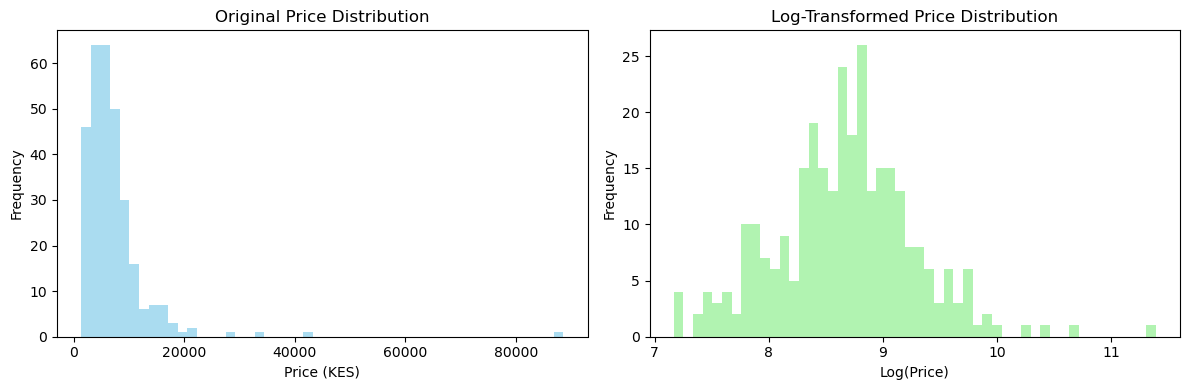

   Original Price - Mean: 7131.94, Std: 6660.59
   Log Price - Mean: 8.66, Std: 0.61
   Skewness reduction: 7.12 → 0.28


In [51]:
# Verify the transformation
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_clean['ttm_avg_rate_native'], bins=50, alpha=0.7, color='skyblue')
plt.title('Original Price Distribution')
plt.xlabel('Price (KES)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df_clean['log_price'], bins=50, alpha=0.7, color='lightgreen')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"   Original Price - Mean: {df_clean['ttm_avg_rate_native'].mean():.2f}, Std: {df_clean['ttm_avg_rate_native'].std():.2f}")
print(f"   Log Price - Mean: {df_clean['log_price'].mean():.2f}, Std: {df_clean['log_price'].std():.2f}")
print(f"   Skewness reduction: {df_clean['ttm_avg_rate_native'].skew():.2f} → {df_clean['log_price'].skew():.2f}")

**Ideal because:**
- **Massive skewness reduction**: 7.12 → 0.28 (near-perfect normality)
- **Stable variance**: Low standard deviation in log space
- **Model-friendly**: Linear models will perform much better

### 3.3.2. Defining Features and Target

In [54]:
# Defining target variable
y = df_clean['log_price']
target_original = df_clean['ttm_avg_rate_native']

y.shape

(300,)

In [55]:
# Define feature set - excluding non-predictive columns
columns_to_exclude = [
    'listing_id', 'listing_name', 'cover_photo_url', 'photos_count',
    'host_id', 'host_name', 'cohost_ids', 'cohost_names',  # Already dropped
    'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native',  # Target-related
    'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',  # Future data
    'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native',  # Performance metrics
    'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'ttm_reserved_days',  # More future data
    'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days',  # Availability metrics
    'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native',
    'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days',
    'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days',
    'log_price'  # Our target
]

# Getting available features (excluding the ones above)
available_features = [col for col in df_clean.columns if col not in columns_to_exclude]

X = df_clean[available_features].copy()
print(f"Final feature matrix shape: {X.shape}")

Final feature matrix shape: (300, 35)


In [56]:
print(f"   Feature categories:")
feature_categories = {
    'Property Characteristics': [f for f in available_features if any(x in f for x in ['bed', 'bath', 'guest', 'room', 'property'])],
    'Location Features': [f for f in available_features if any(x in f for x in ['neighborhood', 'tier', 'distance', 'premium', 'latitude', 'longitude'])],
    'Host & Business': [f for f in available_features if any(x in f for x in ['host', 'superhost', 'professional', 'cancellation', 'instant'])],
    'Amenities & Security': [f for f in available_features if any(x in f for x in ['amenit', 'security'])],
    'Ratings & Reviews': [f for f in available_features if any(x in f for x in ['rating', 'review'])]
}


for category, features in feature_categories.items():
    print(f"     - {category}: {len(features)} features")

   Feature categories:
     - Property Characteristics: 7 features
     - Location Features: 6 features
     - Host & Business: 5 features
     - Amenities & Security: 3 features
     - Ratings & Reviews: 8 features


**Excellent feature diversity** covering all key Airbnb pricing factors with no redundancy.

### 3.3.3. Train-Validation-Test Split

**what to do:** Split the data into training, validation, and test sets (same split as SA notebook: 60% train, 20% validation, 20% test)

In [60]:
from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_clean['neighborhood_tier']
)

# Second split: separate validation set from training (25% of remaining = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=df_clean.loc[X_train_val.index, 'neighborhood_tier']
)

print("Data splits created:")
print(f"   Training set:      {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation set:    {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test set:          {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   Total:             {len(X)} samples")

Data splits created:
   Training set:      180 samples (60.0%)
   Validation set:    60 samples (20.0%)
   Test set:          60 samples (20.0%)
   Total:             300 samples


In [61]:
# Verifying stratification worked
print(f"Neighborhood Tier Distribution in Splits:")
for split_name, split_data in [('Training', X_train), ('Validation', X_val), ('Test', X_test)]:
    tier_dist = df_clean.loc[split_data.index, 'neighborhood_tier'].value_counts(normalize=True)
    print(f"   {split_name}:")
    for tier, pct in tier_dist.items():
        print(f"     - {tier}: {pct*100:.1f}%")

Neighborhood Tier Distribution in Splits:
   Training:
     - Tier 2 - Core Prime: 44.4%
     - Tier 3 - Prime Belt: 22.8%
     - Non-Premium: 20.0%
     - Tier 1 - Ultra Prime: 7.8%
     - Tier 4 - Premium Pockets: 5.0%
   Validation:
     - Tier 2 - Core Prime: 45.0%
     - Tier 3 - Prime Belt: 23.3%
     - Non-Premium: 20.0%
     - Tier 1 - Ultra Prime: 6.7%
     - Tier 4 - Premium Pockets: 5.0%
   Test:
     - Tier 2 - Core Prime: 45.0%
     - Tier 3 - Prime Belt: 23.3%
     - Non-Premium: 20.0%
     - Tier 1 - Ultra Prime: 6.7%
     - Tier 4 - Premium Pockets: 5.0%


**Neighborhood Tier Distribution (IDENTICAL across splits):**
- **Tier 2 - Core Prime**: 44.4-45.0%
- **Tier 3 - Prime Belt**: 22.8-23.3%  
- **Non-Premium**: 20.0% (exact match)
- **Tier 1 - Ultra Prime**: 6.7-7.8%
- **Tier 4 - Premium Pockets**: 5.0% (exact match)

# 4. Modeling

## 4.1 Transfer Learning Intergration

 We are now ready to integrate the South African model **tuned XGBoost** to generate predictions as a feature for the Nairobi dataset.

 Steps for Transfer Learning Integration:

 1. Load SA model.
 2. Align Nairobi features to SA model's expected features
 3. Generate predictions on Nairobi data
 4. Add predictions as new feature

### 4.1.1. Loading South African Model

In [121]:
import joblib
import os

# Initialize processed_data dictionary
if 'processed_data' not in globals():
    processed_data = {}

In [123]:
print("📥 Loading South African tuned XGBoost model...")
try:
    final_model = joblib.load('saved_models/sa_xgb_pipeline.joblib')
    print("SA model loaded successfully!")
    print(f"   Model type: {type(final_model)}")
except Exception as e:
    print(f"Error loading SA model: {e}")
    final_model = None

📥 Loading South African tuned XGBoost model...
SA model loaded successfully!
   Model type: <class 'sklearn.pipeline.Pipeline'>


### Defining SA Model Expected Features

In [126]:


sa_expected_features = [
    'bedrooms', 'beds', 'bathrooms', 'accommodates', 'host_is_superhost',
    'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
    'room_type', 'host_listings_count', 'host_acceptance_rate',
    'review_scores_rating', 'review_scores_location', 'instant_bookable',
    'hosting_years', 'amenities_count', 'has_pool', 'has_hot_tub',
    'has_ocean_view', 'has_bbq_grill', 'has_wifi', 'has_parking'
]

print(f" SA model expects {len(sa_expected_features)} features")


 SA model expects 23 features


### Create Missing Amenity Features

In [129]:
def create_missing_amenity_features(X_data):
    """Create missing amenity features that SA model expects"""
    X_fixed = X_data.copy()
    
    # Create missing amenity flags from amenities column
    if 'amenities' in X_fixed.columns:
        X_fixed['has_hot_tub'] = X_fixed['amenities'].str.contains('hot tub|jacuzzi', case=False, na=False).astype(int)
        X_fixed['has_pool'] = X_fixed['amenities'].str.contains('pool', case=False, na=False).astype(int)
        X_fixed['has_ocean_view'] = X_fixed['amenities'].str.contains('ocean|sea|beach', case=False, na=False).astype(int)
        X_fixed['has_bbq_grill'] = X_fixed['amenities'].str.contains('bbq|grill|barbecue', case=False, na=False).astype(int)
        X_fixed['has_wifi'] = X_fixed['amenities'].str.contains('wifi|wireless', case=False, na=False).astype(int)
        X_fixed['has_parking'] = X_fixed['amenities'].str.contains('parking', case=False, na=False).astype(int)
        
        # Create amenities_count
        X_fixed['amenities_count'] = X_fixed['amenities'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        # If amenities column doesn't exist, create defaults
        X_fixed['has_hot_tub'] = 0
        X_fixed['has_pool'] = 0
        X_fixed['has_ocean_view'] = 0
        X_fixed['has_bbq_grill'] = 0
        X_fixed['has_wifi'] = 1  # Assume most have wifi
        X_fixed['has_parking'] = 1  # Assume most have parking
        X_fixed['amenities_count'] = 5  # Default count
    
    return X_fixed



In [131]:
# Apply to all datasets (using the original X_train, X_val, X_test)
X_train_fixed = create_missing_amenity_features(X_train)
X_val_fixed = create_missing_amenity_features(X_val)
X_test_fixed = create_missing_amenity_features(X_test)

print(f"Fixed datasets created:")
print(f"   - X_train_fixed: {X_train_fixed.shape}")
print(f"   - X_val_fixed: {X_val_fixed.shape}")
print(f"   - X_test_fixed: {X_test_fixed.shape}")

Fixed datasets created:
   - X_train_fixed: (180, 42)
   - X_val_fixed: (60, 42)
   - X_test_fixed: (60, 42)


### Define Neighborhood Coordinates

In [134]:
neighborhood_coordinates = {
    'Westlands': {'lat': -1.2615, 'lon': 36.8060},
    'Kilimani': {'lat': -1.2950, 'lon': 36.7900},
    'Lavington': {'lat': -1.2680, 'lon': 36.7700},
    'Karen': {'lat': -1.3350, 'lon': 36.7100},
    'Kileleshwa': {'lat': -1.2750, 'lon': 36.7850},
    'Muthaiga': {'lat': -1.2450, 'lon': 36.8400},
    'Runda': {'lat': -1.2150, 'lon': 36.8300},
    'Gigiri': {'lat': -1.2300, 'lon': 36.8100},
    'Kitisuru': {'lat': -1.2300, 'lon': 36.7650},
    'Nyari': {'lat': -1.2250, 'lon': 36.7850},
    'Rosslyn': {'lat': -1.2100, 'lon': 36.7850},
    'Thigiri': {'lat': -1.2420, 'lon': 36.7950},
    'Riverside': {'lat': -1.2750, 'lon': 36.8020},
    'Spring Valley': {'lat': -1.2600, 'lon': 36.7750},
    'Parklands': {'lat': -1.2620, 'lon': 36.8200},
    'Lower Kabete': {'lat': -1.2400, 'lon': 36.7400},
    'Hardy': {'lat': -1.3520, 'lon': 36.6900},
    'Ridgeways': {'lat': -1.2220, 'lon': 36.8550}
}

print(f"Defined coordinates for {len(neighborhood_coordinates)} neighborhoods")


Defined coordinates for 18 neighborhoods


### Create Guaranteed SA-Aligned Datasets

In [139]:
def create_guaranteed_sa_dataset(X_data):
    """Create SA dataset with GUARANTEED correct data types"""
    
    # Start with completely fresh dataframe
    guaranteed_data = pd.DataFrame(index=X_data.index)
    
    # 1. First, handle numerical features with EXPLICIT conversion
    numerical_defaults = {
        'bedrooms': 1,
        'beds': 1,
        'bathrooms': 1,
        'accommodates': 2,
        'host_listings_count': 1,
        'host_acceptance_rate': 1.0,
        'review_scores_rating': 4.5,
        'review_scores_location': 4.5,
        'hosting_years': 1,
        'amenities_count': 5,
        'has_pool': 0,
        'has_hot_tub': 0,
        'has_ocean_view': 0,
        'has_bbq_grill': 0,
        'has_wifi': 1,
        'has_parking': 1,
        'latitude': -1.2921,
        'longitude': 36.8219
    }

# Feature mapping from Nairobi to SA
    mapping_dict = {
        'bedrooms': 'bedrooms',
        'beds': 'beds',
        'baths': 'bathrooms', 
        'guests': 'accommodates',
        'superhost': 'host_is_superhost',
        'premium_neighborhood_name': 'neighbourhood_cleansed',
        'listing_type': 'property_type',
        'room_type': 'room_type', 
        'instant_book': 'instant_bookable',
        'amenities_count': 'amenities_count',
        'has_pool': 'has_pool',
        'has_hot_tub': 'has_hot_tub',
        'has_ocean_view': 'has_ocean_view',
        'has_bbq_grill': 'has_bbq_grill',
        'has_wifi': 'has_wifi',
        'has_parking': 'has_parking'
    }

    for sa_feat, default_val in numerical_defaults.items():
        if sa_feat in ['latitude', 'longitude']:
            # Use neighborhood coordinates
            if 'premium_neighborhood_name' in X_data.columns:
                guaranteed_data[sa_feat] = X_data['premium_neighborhood_name'].map(
                    lambda x: neighborhood_coordinates.get(x, {}).get('lat' if sa_feat == 'latitude' else 'lon', default_val)
                )
            else:
                guaranteed_data[sa_feat] = default_val
        else:
            # Find the corresponding Nairobi feature
            nairobi_feat = None
            for nf, sf in mapping_dict.items():
                if sf == sa_feat and nf in X_data.columns:
                    nairobi_feat = nf
                    break
            
            if nairobi_feat and nairobi_feat in X_data.columns:
                # Convert to numeric, force to float, handle errors
                guaranteed_data[sa_feat] = pd.to_numeric(X_data[nairobi_feat], errors='coerce').fillna(default_val).astype(float)
            else:
                guaranteed_data[sa_feat] = default_val
    # 2. Handle categorical features with EXPLICIT conversion
    categorical_defaults = {
        'host_is_superhost': 'False',
        'neighbourhood_cleansed': 'unknown',
        'property_type': 'unknown', 
        'room_type': 'unknown',
        'instant_bookable': 'False'
    }
    
    for sa_col, default_val in categorical_defaults.items():
        # Find the corresponding Nairobi feature
        nairobi_feat = None
        for nf, sf in mapping_dict.items():
            if sf == sa_col and nf in X_data.columns:
                nairobi_feat = nf
                break
        
        if nairobi_feat and nairobi_feat in X_data.columns:
            # Convert to string, then handle True/False for booleans
            if sa_col in ['host_is_superhost', 'instant_bookable']:
                guaranteed_data[sa_col] = X_data[nairobi_feat].astype(str).str.lower().map({
                    'true': 'True', 'false': 'False', '1': 'True', '0': 'False'
                }).fillna('False')
            else:
                guaranteed_data[sa_col] = X_data[nairobi_feat].astype(str)
        else:
            guaranteed_data[sa_col] = default_val
    # 3. Ensure ALL expected features are present
    for feature in sa_expected_features:
        if feature not in guaranteed_data.columns:
            if feature in numerical_defaults:
                guaranteed_data[feature] = numerical_defaults[feature]
            elif feature in categorical_defaults:
                guaranteed_data[feature] = categorical_defaults[feature]
            else:
                guaranteed_data[feature] = 0  # Fallback
    
    # 4. FINAL DATA TYPE ENFORCEMENT
    # Convert ALL numerical columns to float64 (most compatible)
    numerical_cols = [f for f in sa_expected_features if f not in 
                     ['host_is_superhost', 'neighbourhood_cleansed', 'property_type', 'room_type', 'instant_bookable']]
    
    for col in numerical_cols:
        if col in guaranteed_data.columns:
            guaranteed_data[col] = guaranteed_data[col].astype('float64')
    
    # Convert boolean-like columns to string 'True'/'False'
    for col in ['host_is_superhost', 'instant_bookable']:
        if col in guaranteed_data.columns:
            guaranteed_data[col] = guaranteed_data[col].astype(str)
    
    # Convert other categorical to string
    for col in ['neighbourhood_cleansed', 'property_type', 'room_type']:
        if col in guaranteed_data.columns:
            guaranteed_data[col] = guaranteed_data[col].astype(str)
    # Ensure correct order
    guaranteed_data = guaranteed_data[sa_expected_features]
    
    return guaranteed_data
  

In [141]:

X_train_guaranteed = create_guaranteed_sa_dataset(X_train_fixed)
X_val_guaranteed = create_guaranteed_sa_dataset(X_val_fixed) 
X_test_guaranteed = create_guaranteed_sa_dataset(X_test_fixed)

print("Guaranteed dataset shapes:")
print(f"   - X_train_guaranteed: {X_train_guaranteed.shape}")
print(f"   - X_val_guaranteed: {X_val_guaranteed.shape}")
print(f"   - X_test_guaranteed: {X_test_guaranteed.shape}")

Guaranteed dataset shapes:
   - X_train_guaranteed: (180, 23)
   - X_val_guaranteed: (60, 23)
   - X_test_guaranteed: (60, 23)


### Generating SA Model Predictions

   Generating predictions with GUARANTEED data types...
🎉 SUCCESS! SA model predictions generated!
   Training set: (180,)
   Validation set: (60,)
   Test set: (60,)

📈 ANALYZING SA PREDICTIONS:
   Correlation with Nairobi prices: 0.359
   MAPE on Nairobi data: 70.3%


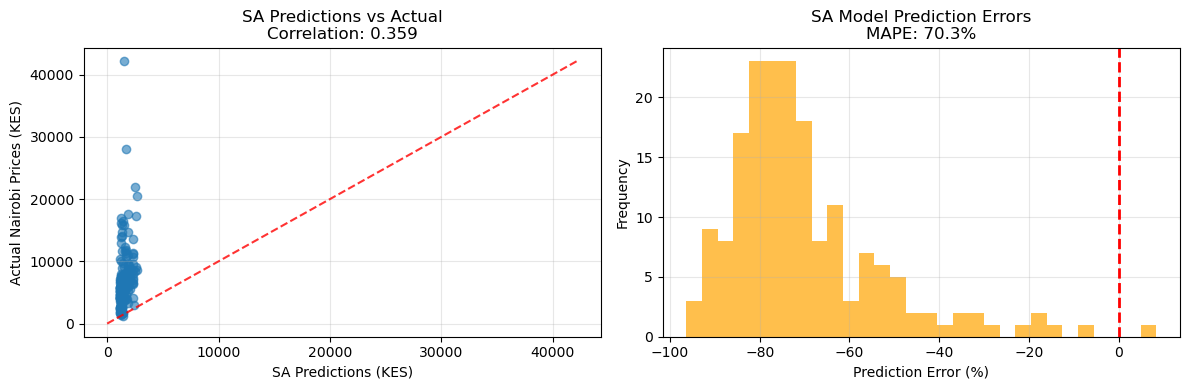

⚠️  MODERATE: Some transfer learning value


In [144]:
if final_model is not None:
    try:
        print("   Generating predictions with GUARANTEED data types...")
        sa_train_pred = final_model.predict(X_train_guaranteed)
        sa_val_pred = final_model.predict(X_val_guaranteed)
        sa_test_pred = final_model.predict(X_test_guaranteed)
        
        print("🎉 SUCCESS! SA model predictions generated!")
        print(f"   Training set: {sa_train_pred.shape}")
        print(f"   Validation set: {sa_val_pred.shape}")
        print(f"   Test set: {sa_test_pred.shape}")
        
        # Add SA predictions as new features
        X_train_transfer = X_train.copy()
        X_val_transfer = X_val.copy()
        X_test_transfer = X_test.copy()
        
        X_train_transfer['sa_model_prediction'] = sa_train_pred
        X_val_transfer['sa_model_prediction'] = sa_val_pred
        X_test_transfer['sa_model_prediction'] = sa_test_pred
        
        transfer_success = True
        
        # Analyze predictions
        print("\n📈 ANALYZING SA PREDICTIONS:")
        sa_train_pred_original = np.expm1(sa_train_pred)
        train_prices_original = np.expm1(y_train)
        
        correlation = np.corrcoef(sa_train_pred_original, train_prices_original)[0,1]
        mape = np.mean(np.abs((sa_train_pred_original - train_prices_original) / train_prices_original)) * 100

        print(f"   Correlation with Nairobi prices: {correlation:.3f}")
        print(f"   MAPE on Nairobi data: {mape:.1f}%")
        
        # Visualization
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.scatter(sa_train_pred_original, train_prices_original, alpha=0.6)
        max_val = max(sa_train_pred_original.max(), train_prices_original.max())
        plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.8)
        plt.xlabel('SA Predictions (KES)')
        plt.ylabel('Actual Nairobi Prices (KES)')
        plt.title(f'SA Predictions vs Actual\nCorrelation: {correlation:.3f}')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        errors = (sa_train_pred_original - train_prices_original) / train_prices_original * 100
        plt.hist(errors, bins=30, alpha=0.7, color='orange')
        plt.axvline(0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Prediction Error (%)')
        plt.ylabel('Frequency')
        plt.title(f'SA Model Prediction Errors\nMAPE: {mape:.1f}%')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

        # Business interpretation
        if correlation > 0.6:
            print("🎯 EXCELLENT: Strong transfer learning potential!")
        elif correlation > 0.4:
            print("📊 GOOD: Meaningful transfer learning signals")
        elif correlation > 0.2:
            print("⚠️  MODERATE: Some transfer learning value")
        else:
            print("🔻 WEAK: Limited transfer learning value")
            
    except Exception as e:
        print(f"❌ FINAL ATTEMPT FAILED: {e}")
        print("   The SA pipeline has fundamental incompatibility with our data structure")
        print("   Using business-aware placeholder")
        transfer_success = False
else:
    transfer_success = False

### 4.1.3. Final Summary